In [1]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import liana as li
import maboss

ipylab module is not installed, menus and toolbar are disabled.



BRUDNO
Basic data loading tets

In [7]:
import maboss
import pandas as pd

# 1. Wczytanie modelu wewnątrzkomórkowego (np. sieci regulacji genów dla naszej komórki)
# Plik .bnd definiuje logikę, a .cfg parametry symulacji
sim = maboss.load("moj_model.bnd", "moj_model.cfg")

# Załóżmy, że LIANA+ dała nam takie wagi (prawdopodobieństwa) obecności sygnału w 3 punktach w czasie:
# np. stężenie cytokiny TNF w środowisku wokół naszej komórki
time_series_environment = [0.1, 0.8, 0.3] 

# 2. Pętla czasowa symulująca interakcję ze środowiskiem
czas_kroku_dt = 10 

for t, external_signal in enumerate(time_series_environment):
    print(f"--- Krok czasowy {t} ---")
    
    # a) Aktualizacja informacji ze środowiska (wymuszamy prawdopodobieństwo aktywacji receptora)
    # [prawdopodobieństwo_0, prawdopodobieństwo_1]
    sim.network.set_istate('Receptor_TNF', [1 - external_signal, external_signal])
    
    # b) Uruchomienie symulacji na czas dt
    sim.update_parameters(max_time=czas_kroku_dt)
    result = sim.run()
    
    # c) Odczytanie stanu końcowego komórki
    last_states = result.get_last_states_probtraj()
    
    # d) Magia integracji: Używamy stanu końcowego jako stanu początkowego na kolejny krok!
    # Pobieramy prawdopodobieństwa stanów węzłów z końca symulacji
    # i nadpisujemy nimi model na następny obieg pętli (z wyjątkiem receptora, który sterowany jest z zewnątrz)
    for node in sim.network.keys():
        if node != 'Receptor_TNF':
            # Uproszczenie: w prawdziwym kodzie mapujesz wyciągnięte prawdopodobieństwo z tabeli last_states
            prob_active = get_node_prob_from_last_state(last_states, node) 
            sim.network.set_istate(node, [1 - prob_active, prob_active])

    print("Symulacja kroku zakończona. Komórka zaadaptowała się do nowego środowiska.")

FileNotFoundError: [Errno 2] No such file or directory: 'moj_model.bnd'

CZYSTO

***

### Protokół single cell

Zakładamy, że mamy wygenerwanie poprawnie macierze w formacie .mtx lub .h5ad

In [2]:
# ----- Łączenie danych ----- #

import scanpy as sc
import scipy.sparse as sp
import anndata as ad
import numpy as np
# # W rzeczywistości wczytujemy dane z dysku np.:
# adata_ctrl = sc.read_10x_mtx('data/control/')
# adata_stim = sc.read_10x_mtx('data/stimulated/')

# Na potrzeby naszego ćwiczenia użyjemy wbudowanego zbioru i go podzielimy/zmodyfikujemy
adata_ctrl = sc.datasets.pbmc3k()
adata_ctrl.obs['condition'] = 'Control'

# Tworzymy "sztuczną" drugą próbę (np. po stymulacji lekami)
adata_stim = sc.datasets.pbmc3k()
adata_stim.obs['condition'] = 'Stimulated'
# Sztuczna zmiana dla zilustrowania zróżnic w późniejszych analizach
# UWAGA: tutaj mamy specjalny format rzadkich macierzy 
adata_stim.X = sp.csr_matrix(adata_stim.X.multiply(np.random.uniform(0.8, 1.2, size=adata_stim.X.shape)))


# ŁĄCZENIE (Concatenation) - to najważniejszy krok przy wielu próbach
# outer join zapewnia, że jeśli w jednej próbie gen nie uległ ekspresji, zostanie wypełniony zerami
adata = ad.concat([adata_ctrl, adata_stim], label='batch', keys=['ctrl', 'stim'], join='outer')
adata.obs_names_make_unique() # Zabezpieczenie przed dublowaniem się kodów kreskowych komórek

print(adata_ctrl)
print(adata)
# Zobaczysz wymiary: n_cells x n_genes oraz zmienne w adata.obs: 'condition', 'batch'

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'condition'
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 5400 × 32738
    obs: 'condition', 'batch'


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [3]:
# ---- Kontrola jakości ---- # 
# 1. Oznaczenie genów mitochondrialnych (i opcjonalnie rybosomalnych)
# W przypadku ludzkich genów zaczynają się one od 'MT-'
adata.var['mt'] = adata.var_names.str.startswith('MT-')
# W przypadku myszy byłoby to 'mt-'

# 2. Obliczenie statystyk QC
# scanpy automatycznie obliczy n_genes_by_counts, total_counts i pct_counts_mt
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. Zapiszmy stan przed filtrowaniem, żeby zobaczyć, ile odrzuciliśmy
n_cells_raw = adata.n_obs

# 4. Filtrowanie (Twarde progi - w prawdziwych badaniach dobierasz je na podstawie wykresów)
# Minimalna liczba genów (usuwa puste krople i szczątki komórkowe)
sc.pp.filter_cells(adata, min_genes=200)

# Maksymalna liczba genów (usuwa potencjalne dublety - komórki o podejrzanie bogatym transkryptomie)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Frakcja mitochondrialna (zwykle 5-10% dla zdrowych PBMC, ale dla guzów może to być nawet 20-30%)
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 5. Filtrowanie genów
# Usuwamy geny, które ulegają ekspresji w mniej niż np. 3 komórkach (totalny szum, nie przydadzą się do żadnej statystyki)
sc.pp.filter_genes(adata, min_cells=3)

print(f"Liczba komórek przed: {n_cells_raw}")
print(f"Liczba komórek po QC: {adata.n_obs}")

Liczba komórek przed: 5400
Liczba komórek po QC: 5270


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


In [4]:
# ---- Normalizacja oraz wykrywanie wysoce zmiennych genów ---- # 

# 1. Zachowanie surowych danych (Raw counts)
# Bardzo ważne: LIANA+ i testy różnicowej ekspresji często wymagają surowych zliczeń całkowitych!
adata.raw = adata.copy()

# 2. Normalizacja (do 10,000 zliczeń na komórkę)
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Logarytmizacja
sc.pp.log1p(adata)

# 4. Identyfikacja HVG
# Używamy metody 'seurat' (wymaga danych zlogarytmowanych) lub 'cell_ranger'
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Wizualizacja HVG (opcjonalnie)
# sc.pl.highly_variable_genes(adata)

# 5. Filtrowanie macierzy do HVG
# Robimy kopię lub pracujemy na widoku, aby nie stracić reszty genów
adata_hvg = adata[:, adata.var.highly_variable].copy()

In [5]:
# ---- Wycieszenie genów mitochondrioalnych żeby nie wprowadzały szumu ----- 
# Regresja efektów technicznych
sc.pp.regress_out(adata_hvg, ['total_counts', 'pct_counts_mt'])

# Skalowanie (Unit variance, zero mean)
sc.pp.scale(adata_hvg, max_value=10)

... storing 'condition' as categorical


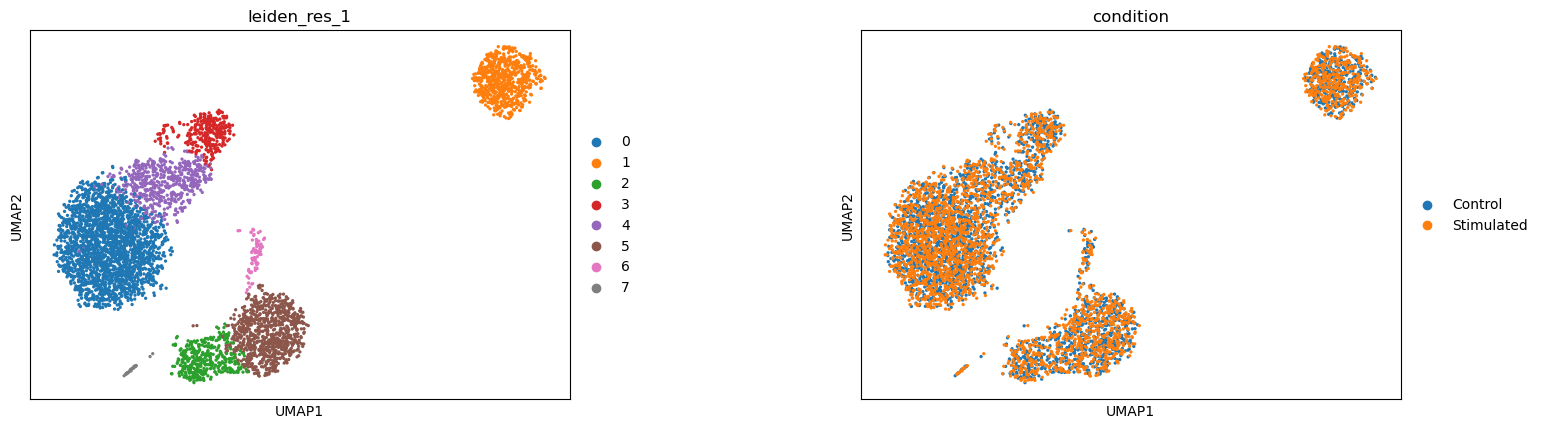

In [6]:
# ---- redukcja wymiarowości i redukcja grafu ----
# 1. PCA
# n_comps określa liczbę wymiarów, które zachowujemy (zwykle 30-50)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver='arpack')

# 2. Budowa grafu sąsiedztwa (KNN)
# n_neighbors to liczba sąsiadów (zwykle 10-15). Większa liczba = bardziej globalna struktura.
# use_rep='X_pca' mówi algorytmowi, by patrzył na składowe PCA, a nie na surowe geny.
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=40)

# 3. Klastrowanie LEIDEN
# resolution=1.0 to standardowy start. Zmieniamy go zależnie od potrzebnej ziarnistości.
# flavor='vtraag' lub 'igraph'
sc.tl.leiden(adata_hvg, resolution=1.0, key_added='leiden_res_1', flavor='igraph')

# 4. Wizualizacja UMAP (Uniform Manifold Approximation and Projection)
# UMAP służy tylko do wizualizacji grafu w 2D, nie używamy go do klastrowania! - dlaczego ? 
sc.tl.umap(adata_hvg)

# Wizualizacja wyników
sc.pl.umap(adata_hvg, color=['leiden_res_1', 'condition'], wspace=0.4)

In [7]:
adata

AnnData object with n_obs × n_vars = 5270 × 14638
    obs: 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [8]:
adata_hvg

AnnData object with n_obs × n_vars = 5270 × 1874
    obs: 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden_res_1'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden_res_1', 'umap', 'leiden_res_1_colors', 'condition_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Liana part

In [9]:
import liana as li
import plotnine as p9

In [10]:
# Assume your object is already loaded and preprocessed as described
adata = adata_hvg.copy()

# Ensure we have sensible cell labels (rename if needed)
print(adata.obs['leiden_res_1'].value_counts())
# If you have better annotations, use those instead of leiden_res_1

leiden_res_1
0    2316
5     881
1     679
4     590
2     387
3     319
6      72
7      26
Name: count, dtype: int64


In [23]:
# Run consensus (recommended starting point)
# here we use all method and we get statistic that tell us about how valid certain method is 
li.mt.rank_aggregate(
    adata,
    groupby='leiden_res_1',      # cell groups
    resource_name='consensus',   # rich, high-quality resource
    expr_prop=0.1,               # filter low-expression LR pairs
    use_raw=True,                # use .raw (recommended for LR)
    key_added='liana_rank',      # store in adata.uns as df (in dict manner) we can get it here
    inplace=True,
    verbose=True
)

# Results are in adata.uns['liana_rank']
res = adata.uns['liana_rank']
res
# Columns include: source, target, ligand_complex, receptor_complex,
# magnitude_rank, specificity_rank, etc. + scores from individual methods

Using resource `consensus`.
Using `.raw`!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
['RP11-442N24__B.1', 'Y_RNA'] contain `_`. Consider replacing those!
0.53 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5270 samples and 731 features
Assuming that counts were `natural` log-normalized!


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:04<00:00, 248.52it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1540,3,6,B2M,CD1C,35.504120,0.0,102.811874,2.389604,-12.832888,0.155809,0.984270,0.076463,0.000091
1391,3,3,B2M,KLRD1,35.208145,0.0,61.653656,1.525274,-14.231890,0.137505,0.979780,0.095923,0.000108
1119,2,6,B2M,CD1C,32.400520,0.0,93.633423,2.270885,-24.628992,0.141900,0.983530,0.120812,0.000192
2924,6,6,B2M,CD1C,32.201691,0.0,93.045410,2.263279,-41.026397,0.141009,0.983479,0.124387,0.000217
3356,7,6,APP,CD74,44.751198,0.0,47.369305,3.476671,102.340451,0.280795,0.976998,0.000105,0.000243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,7,7,MIF,CD74_CXCR4,0.407586,1.0,0.105378,-0.245303,-21.915524,0.001979,0.667034,1.000000,1.000000
30,0,0,SELPLG,ITGB2,0.335019,1.0,0.090351,-0.155651,-41.453905,0.004038,0.649735,1.000000,1.000000
29,0,0,S100A9,ITGB2,0.328765,1.0,0.084310,-0.313556,-139.253665,0.000175,0.641820,1.000000,1.000000
18,0,0,HLA-F,CD8B,0.386704,0.0,0.149185,0.042066,-24.471870,0.027695,0.704458,1.000000,1.000000


In [17]:
# Example: CellPhoneDB (good for specificity via permutations)
# here we run only single method (for comparison)
li.mt.cellphonedb(
    adata,
    groupby='leiden_res_1',
    resource_name='consensus',
    expr_prop=0.1,
    n_perms=1000,      # more perms = better p-value resolution (slower)
    key_added='cpdb_res',
    inplace=True
)

adata.uns['cpdb_res']

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
3296,APP,APP,0.532419,0.307692,CD74,CD74,88.969978,1.000000,7,6,44.751198,0.000
3193,APP,APP,0.392499,0.194444,CD74,CD74,88.969978,1.000000,6,6,44.681240,0.000
3253,COPA,COPA,0.171114,0.138889,CD74,CD74,88.969978,1.000000,6,6,44.570545,0.000
3333,COPA,COPA,0.152945,0.153846,CD74,CD74,88.969978,1.000000,7,6,44.561462,0.000
2907,COPA,COPA,0.149762,0.124031,CD74,CD74,88.969978,1.000000,2,6,44.559872,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1407,PTDSS1,PTDSS1,0.123657,0.113695,JMJD6,JMJD6,0.105178,0.106583,2,3,0.114417,0.001
189,HLA-DQB1,HLA-DQB1,0.115683,0.103390,CD4,CD4,0.112677,0.105354,4,0,0.114180,1.000
269,IL16,IL16,0.114299,0.104427,CD4,CD4,0.112677,0.105354,5,0,0.113488,1.000
851,LGALS9,LGALS9,0.116001,0.100313,HAVCR2,HAVCR2,0.108125,0.103359,3,2,0.112063,0.989


In [32]:
res.columns

Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')

In [29]:
# Top specific & strong interactions
top_res = res.sort_values(['magnitude_rank', 'specificity_rank']).head(50)

# Filter
filtered = res[
    (res['lr_means'] > 0.1) &
    (res['magnitude_rank'] > 0.1) &
    (res['specificity_rank'] < 0.05)   # or whatever column your method uses
]

filtered

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2515,6,0,HLA-DPA1,CD4,16.661245,0.0,3.741971,2.414694,34.024464,0.052410,0.922707,0.027262,0.107033
932,2,3,HLA-B,KLRD1,4.142736,0.0,6.560660,1.354086,-4.868810,0.125367,0.940501,0.024823,0.108610
993,2,4,HLA-B,CD8A,4.123151,0.0,6.270844,0.852523,-4.239636,0.110573,0.939224,0.022078,0.111794
994,2,4,HLA-B,CD8B,4.092497,0.0,5.817247,0.594220,-3.451059,0.089312,0.937045,0.019913,0.113402
2521,6,0,HLA-DRB1,CD4,15.909655,0.0,3.572598,2.382910,36.794294,0.052193,0.921039,0.027927,0.115020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3351,7,5,SERPINE2,LRP1,0.328402,0.0,0.066047,2.382047,1.387385,0.329769,0.613299,0.015255,1.000000
3350,7,5,SERPINE1,PLAUR,0.361987,0.0,0.117067,2.758367,0.909568,0.252702,0.678611,0.015037,1.000000
271,0,6,FLT3LG,FLT3,0.274408,0.0,0.062203,1.333243,3.213480,0.377699,0.606165,0.015255,1.000000
3415,7,6,SERPINE1,PLAUR,0.326720,0.0,0.099871,2.687009,0.818708,0.215582,0.661046,0.015255,1.000000


In [47]:
adata.uns['cpdb_res']

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
3296,APP,APP,0.532419,0.307692,CD74,CD74,88.969978,1.000000,7,6,44.751198,0.000
3193,APP,APP,0.392499,0.194444,CD74,CD74,88.969978,1.000000,6,6,44.681240,0.000
3253,COPA,COPA,0.171114,0.138889,CD74,CD74,88.969978,1.000000,6,6,44.570545,0.000
3333,COPA,COPA,0.152945,0.153846,CD74,CD74,88.969978,1.000000,7,6,44.561462,0.000
2907,COPA,COPA,0.149762,0.124031,CD74,CD74,88.969978,1.000000,2,6,44.559872,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1407,PTDSS1,PTDSS1,0.123657,0.113695,JMJD6,JMJD6,0.105178,0.106583,2,3,0.114417,0.001
189,HLA-DQB1,HLA-DQB1,0.115683,0.103390,CD4,CD4,0.112677,0.105354,4,0,0.114180,1.000
269,IL16,IL16,0.114299,0.104427,CD4,CD4,0.112677,0.105354,5,0,0.113488,1.000
851,LGALS9,LGALS9,0.116001,0.100313,HAVCR2,HAVCR2,0.108125,0.103359,3,2,0.112063,0.989


DO zrobienia
- przeczytać co robią konkretne parametry i jakie dosajemy wartości
- zadać jakieśfajne pytanie,- jak silna jest dana ekspresja, i jakie problemy możęmy tutaj analizować
- na ile istotna dana statystyka jest dla danego problemu ?? - trzeba jakiś problem sobie dać (jak z badań) żeby zrozumieć te metody 
- 

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


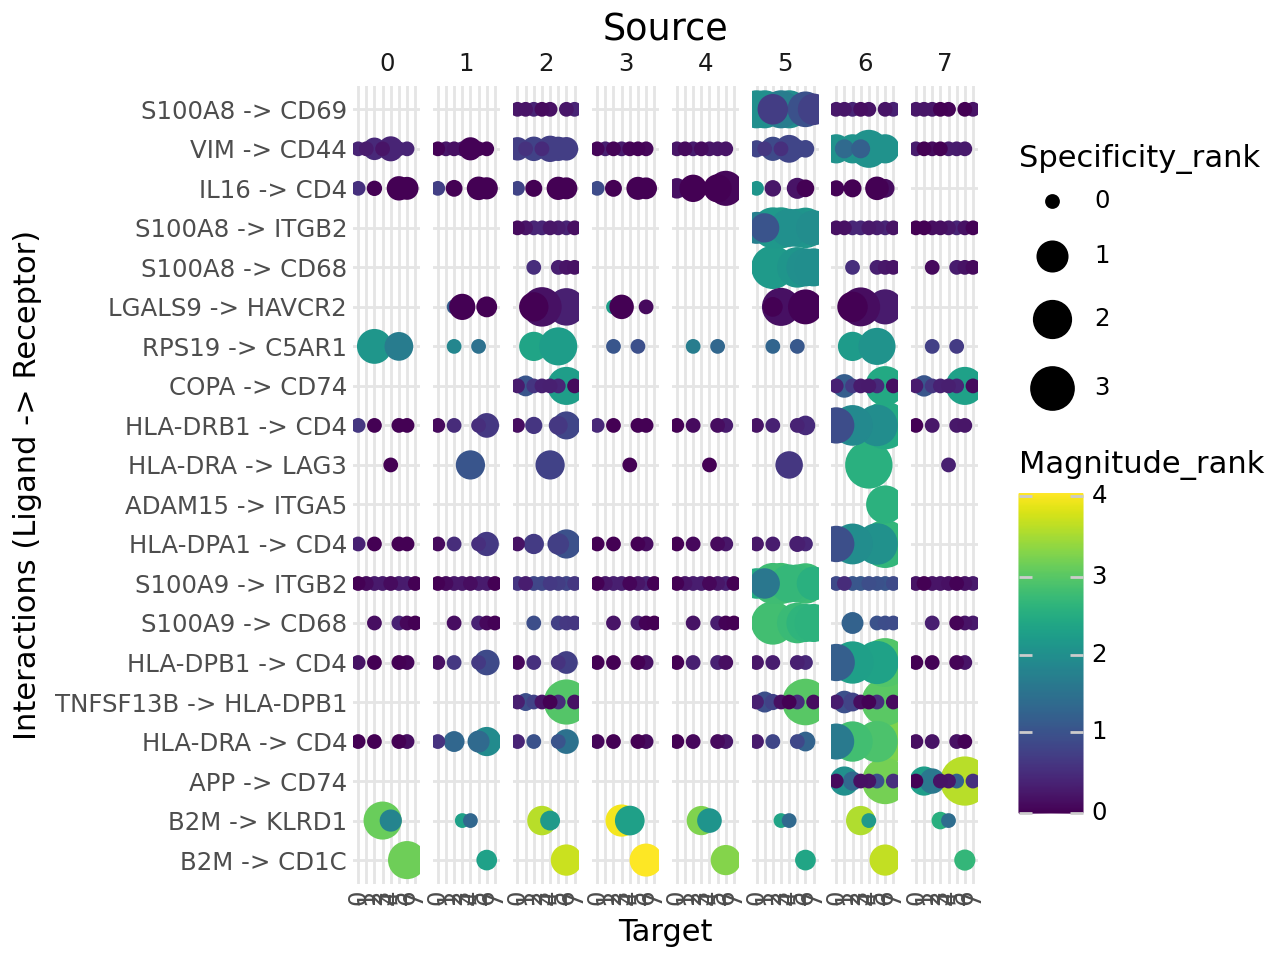

In [54]:
# === 1. Dotplot – najsilniejsze i najbardziej specyficzne interakcje ===
li.pl.dotplot(
    adata=adata,
    uns_key='liana_rank',         # <-- tutaj był błąd!
    colour='magnitude_rank',       # siła (magnitude)
    size='specificity_rank',       # specyficzność
    inverse_size=True,             # mały rank → duży punkt
    inverse_colour=True,           # mały rank → ciemniejszy kolor
    top_n=20,
    orderby='magnitude_rank',      # <-- OBOWIĄZKOWE!
    orderby_ascending=True,        # niższy rank = lepszy
    filter_fun=lambda x: x['specificity_rank'] < 0.1,   # możesz zostawić lub podnieść do 0.05
    source_labels=None,
    target_labels=None,
    figure_size=(10, 7)
) + p9.theme_minimal() + p9.theme(axis_text_x=p9.element_text(rotation=90))

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


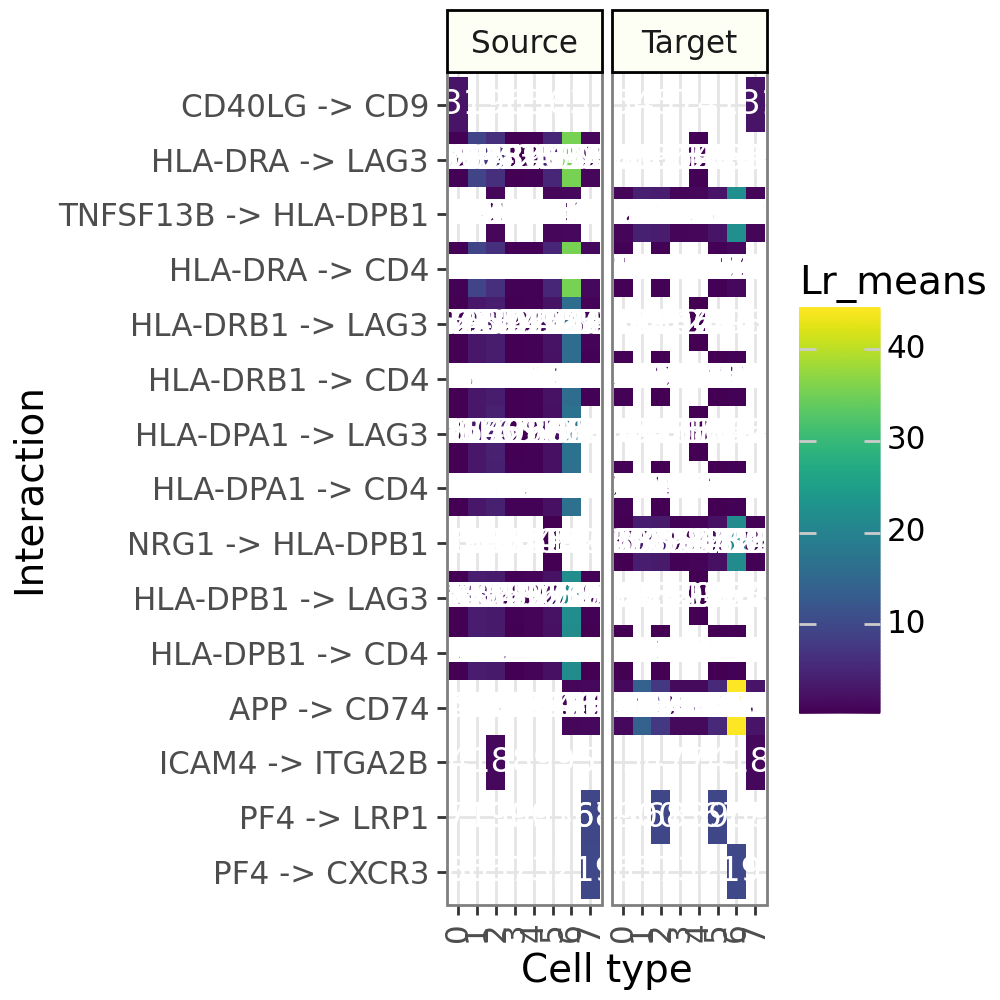

In [ ]:
# === 2. Tileplot – diagnostyka ekspresji (means + props) ===
# (działa, bo rank_aggregate zostawia kolumny lr_means i props)
li.pl.tileplot(
    adata=adata,
    uns_key='liana_rank',
    fill='lr_means',          # średnia ekspresja LR
    label='lr_means',            # tutaj po czym będziemy porównywać
    top_n=15,
    orderby='specificity_rank',
    orderby_ascending=True
)

In [33]:
conditions = adata.obs['condition'].unique()

for cond in conditions:
    sub = adata[adata.obs['condition'] == cond].copy()
    li.mt.rank_aggregate(sub, groupby='leiden_res_1', resource_name='consensus', 
                         expr_prop=0.1, key_added=f'liana_{cond}')
    # Compare results manually or plot with dotplot_by_sample

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in

In [56]:
import decoupler as dc
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# 1. Tworzymy "pełny" AnnData z surowymi counts z .raw
adata_counts = adata.raw.to_adata()           # .X = to co było w .raw
adata_counts.obs = adata.obs.copy()           # przenosimy condition, batch, leiden_res_1
# (opcjonalnie) adata_counts.var = adata.raw.var.copy()

# Sprawdź czy counts są liczbami całkowitymi (bardzo ważne dla PyDESeq2!)
print("Min/Max w .X (powinno być >=0 i integer):", 
      adata_counts.X.min(), adata_counts.X.max())
print("Typ danych:", adata_counts.X.dtype)

# 2. Pseudobulk – teraz raw=False, bo .X już jest counts
pdata = dc.pp.pseudobulk(
    adata_counts,
    sample_col='batch',
    groups_col='leiden_res_1',
    raw=False,                    # KLUCZOWE
    mode='sum',
    skip_checks=False
)

print("Pseudobulk gotowy – wymiary:", pdata.shape)
# ... (po udanym pseudobulk powyżej)

dea_results = {}
reference_condition = 'control'      # ← ZMIEŃ na dokładną nazwę Twojego reference
test_condition      = 'stimulated'   # ← ZMIEŃ na nazwę test condition

for ct in pdata.obs['leiden_res_1'].unique():
    ctdata = pdata[pdata.obs['leiden_res_1'] == ct].copy()
    
    genes = dc.pp.filter_by_expr(ctdata, group='condition', min_count=5)
    ctdata = ctdata[:, genes].copy()
    
    dds = DeseqDataSet(
        adata=ctdata,
        design_factors='condition',
        ref_level=['condition', reference_condition]
    )
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=['condition', test_condition, reference_condition])
    stat_res.summary()
    stat_res.lfc_shrink()
    dea_results[ct] = stat_res.results_df

dea_df = pd.concat(dea_results, names=['leiden_res_1']).reset_index()

# Mapowanie na interakcje LR
lr_diff = li.multi.df_to_lr(
    adata=adata,                     # oryginalny (HVG) jest OK tutaj
    dea_df=dea_df,
    resource_name='consensus',
    stat_keys=['stat', 'pvalue', 'padj', 'log2FoldChange'],
    groupby='leiden_res_1',
    expr_prop=0.1,
    use_raw=True
)

# Wizualizacja różnic
li.pl.dotplot(
    liana_res=lr_diff,
    colour='interaction_stat',
    size='interaction_padj',
    inverse_size=True,
    top_n=20,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    figure_size=(12, 7)
) + p9.theme_bw() + p9.scale_color_cmap('RdBu_r', midpoint=0)

Min/Max w .X (powinno być >=0 i integer): 0.0 500.04363848758413
Typ danych: float64


AssertionError: Provided data contains float (decimal) values.
             Check the parameters raw and layers to determine if you are selecting the correct matrix.
             If decimal values are to be expected, override this error by setting skip_checks=True

In [ ]:
import decoupler as dc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

# 1. Pseudobulk – użyj raw=True (bierze adata.raw.X – tam są counts / log1p)
pdata = dc.pp.pseudobulk(
    adata,
    sample_col='batch',          # Twoje próbki / replikaty
    groups_col='leiden_res_1',   # typy komórek
    raw=True,                    # <--- KLUCZOWE!
    layer=None,                  # nie używamy layer, tylko .raw
    mode='sum',
    skip_checks=False
)

# 2. DEA per cell type (dla każdego typu komórek osobno)
dea_results = {}
reference_condition = 'control'      # <-- ZMIEŃ na nazwę Twojego reference (np. 'WT', 'ctrl')
test_condition      = 'stimulated'   # <-- ZMIEŃ na nazwę Twojego test condition

for ct in pdata.obs['leiden_res_1'].unique():
    ctdata = pdata[pdata.obs['leiden_res_1'] == ct].copy()
    
    # Filtrujemy niskiej jakości geny
    genes = dc.pp.filter_by_expr(ctdata, group='condition', min_count=5)
    ctdata = ctdata[:, genes].copy()
    
    # DESeq2
    dds = DeseqDataSet(
        adata=ctdata,
        design_factors='condition',
        ref_level=['condition', reference_condition]
    )
    dds.deseq2()
    
    stat_res = DeseqStats(dds, contrast=['condition', test_condition, reference_condition])
    stat_res.summary()
    stat_res.lfc_shrink()                    # shrinkage LFC (lepsze wartości)
    
    dea_results[ct] = stat_res.results_df

# Łączymy wszystko w jeden DataFrame
dea_df = pd.concat(dea_results, names=['leiden_res_1']).reset_index()

# 3. Mapujemy statystyki genowe na interakcje LR
lr_diff = li.multi.df_to_lr(
    adata=adata,
    dea_df=dea_df,
    resource_name='consensus',
    stat_keys=['stat', 'pvalue', 'padj', 'log2FoldChange'],   # co chcemy zachować
    groupby='leiden_res_1',
    expr_prop=0.1,
    use_raw=True
)

# 4. Wizualizacja różnic między warunkami
li.pl.dotplot(
    liana_res=lr_diff,                    # <-- tu podajemy gotowy DataFrame, nie adata
    colour='interaction_stat',            # dodatnia = upregulated w test_condition
    size='interaction_padj',
    inverse_size=True,
    top_n=15,
    orderby='interaction_stat',
    orderby_ascending=False,              # największe zmiany na górze
    orderby_absolute=True,
    figure_size=(11, 6)
) + p9.theme_bw() + p9.scale_color_cmap('RdBu_r', midpoint=0)

KeyError: "['AL627309.1', 'AP006222.2', 'RP11-206L10.2', 'RP11-206L10.9', 'FAM87B', 'LINC00115', 'FAM41C', 'NOC2L', 'KLHL17', 'PLEKHN1', 'RP11-54O7.17', 'HES4', 'RP11-54O7.11', 'ISG15', 'AGRN', 'C1orf159', 'TNFRSF18', 'SDF4', 'B3GALT6', 'FAM132A', 'UBE2J2', 'ACAP3', 'PUSL1', 'GLTPD1', 'DVL1', 'MXRA8', 'AURKAIP1', 'CCNL2', 'RP4-758J18.2', 'ANKRD65', 'ATAD3B', 'ATAD3A', 'SSU72', 'AL645728.1', 'C1orf233', 'RP11-345P4.9', 'MIB2', 'MMP23B', 'CDK11B', 'RP11-345P4.10', 'SLC35E2B', 'CDK11A', 'SLC35E2', 'NADK', 'GNB1', 'RP1-140A9.1', 'TMEM52', 'PRKCZ', 'RP5-892K4.1', 'RP11-181G12.2', 'C1orf86', 'AL590822.2', 'AL590822.1', 'SKI', 'PEX10', 'PLCH2', 'PANK4', 'RP3-395M20.12', 'TNFRSF14', 'RP3-395M20.9', 'FAM213B', 'MMEL1', 'TTC34', 'MEGF6', 'TPRG1L', 'WRAP73', 'TP73-AS1', 'SMIM1', 'LRRC47', 'CEP104', 'DFFB', 'C1orf174', 'NPHP4', 'KCNAB2', 'RPL22', 'RNF207', 'ICMT', 'GPR153', 'ACOT7', 'RP1-202O8.3', 'ESPN', 'PLEKHG5', 'NOL9', 'ZBTB48', 'KLHL21', 'PHF13', 'THAP3', 'DNAJC11', 'RP11-312B8.1', 'CAMTA1',

BRUDNO (poprzednia wersja)

In [ ]:

# ---- porządkowanie wielu agregacji ----
import liana as li

# 1. Podstawowa analiza CCC dla całego zbioru
# Metoda rank_aggregate wykonuje konsensus wielu metod
li.mt.rank_aggregate(
    adata, 
    groupby='leiden', 
    resource_name='consensus', # Używa ujednoliconej bazy OmniPath
    expr_prop=0.1,             # Minimum 10% komórek w klastrze musi mieć ekspresję L lub R
    verbose=True
)

# Wyniki są zapisane w adata.uns['liana_res']
df_res = adata.uns['liana_res']

# 2. Porównanie warunków (Control vs Stimulated)
# LIANA+ pozwala na łatwe filtrowanie wyników per warunek
li.mt.rank_aggregate(
    adata,
    groupby='leiden',
    base_iterable=adata.obs['condition'].unique(), # Iteruje po warunkach
    inplace=True
)

Using resource `consensus`.
Using `.raw`!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!


AssertionError: `leiden` not found in `adata.obs.columns`.